# Loading Modules & Data

In [51]:
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Setting environment to ignore future warnings
import warnings
warnings.simplefilter('ignore')


pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

In [52]:
df = pd.read_csv("/Users/jaynahalai/Desktop/Customer-Vunerability/data/cleaned_data_stage1.csv")
df.head(2)

,Feedback ID,Date received,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,Sub-issue,Consumer complaint narrative,State,Date sent to company,Company response to consumer,Timely response?,gender_cat,age,rejected,Recommended Pathway Switch,income,children,vulnerability category,negative,positive,neutral,sentiment,Channel_of_communication,job,education,cust_ID,20,vulnerability_score,vulnerability_level,Self Disclosed Vulnerability,escalated to ombudsman,High level issue,Product_type
0,3186792,2019-03-21,Theft,Credit reporting,non-vunerable,Dec-24,Repayment,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,There is an account reporting on my credit rep...,GA,2019-03-21,Closed with explanation,Yes,Male,27.0,0,No Change,72578.64234,0,Poor or non-existent digital skills,0.037,0.189,0.774,negative,Chatbot,management,secondary,1749229,1523,0,Level 0 - not vulnerable,0,0,billing disputes,Home insurance
1,3184692,2019-03-19,Occupational Health,Credit reporting,non-vunerable,24+,Misselling,Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,XXXX and Transunion are reporting incorrectly ...,MO,2019-03-19,Closed with explanation,Yes,Female,29.0,0,No Change,55951.19927,1,learning difficulties,0.084,0.036,0.880,neutral,Mobile App,unemployed,secondary,1749230,1514,0,Level 0 - not vulnerable,0,0,product modification,Health insurance


In [53]:
df.columns.to_list()

['Feedback ID',
 'Date received',
 'Product',
 'Sub-product',
 'vunerable_customer',
 'cancelation_period_month',
 'issue_source',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'State',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'gender_cat',
 'age',
 'rejected',
 'Recommended Pathway Switch',
 'income',
 'children',
 'vulnerability category',
 'negative',
 'positive',
 'neutral',
 'sentiment',
 'Channel_of_communication',
 'job',
 'education',
 'cust_ID',
 '20',
 'vulnerability_score',
 'vulnerability_level',
 'Self Disclosed Vulnerability',
 'escalated to ombudsman',
 'High level issue',
 'Product_type']

# Feature Engineering

In [54]:
IDs = ["Feedback ID", "cust_ID"]
df.drop(IDs, axis=1, inplace=True)

In [55]:
dates = ["Date received", "Date sent to company"]
df.drop(dates, axis=1, inplace=True)

In [56]:
df["rejected"] = df["rejected"].astype("object")
df["children"] = df["children"].astype("object")
df["vulnerability_score"] = df["vulnerability_score"].astype("object")
df["Self Disclosed Vulnerability"] = df["Self Disclosed Vulnerability"].astype("object")
df["escalated to ombudsman"] = df["escalated to ombudsman"].astype("object")

In [57]:
import scipy.stats as ss
def calculate_cramers_v(x, y):
    
    # plotting confusion matrix
    confusion_matrix = pd.crosstab(x,y)
    # finding chi_score
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

In [58]:
cols = ["Consumer complaint narrative", "vulnerability_level"]
cat_columns = df.select_dtypes("O").drop(cols, axis=1).columns

data = []
for i in cat_columns:
    row = []
    for j in cat_columns:
        res = calculate_cramers_v(df[i], df[j])
        row.append(round(res, 3))
    data.append(row)

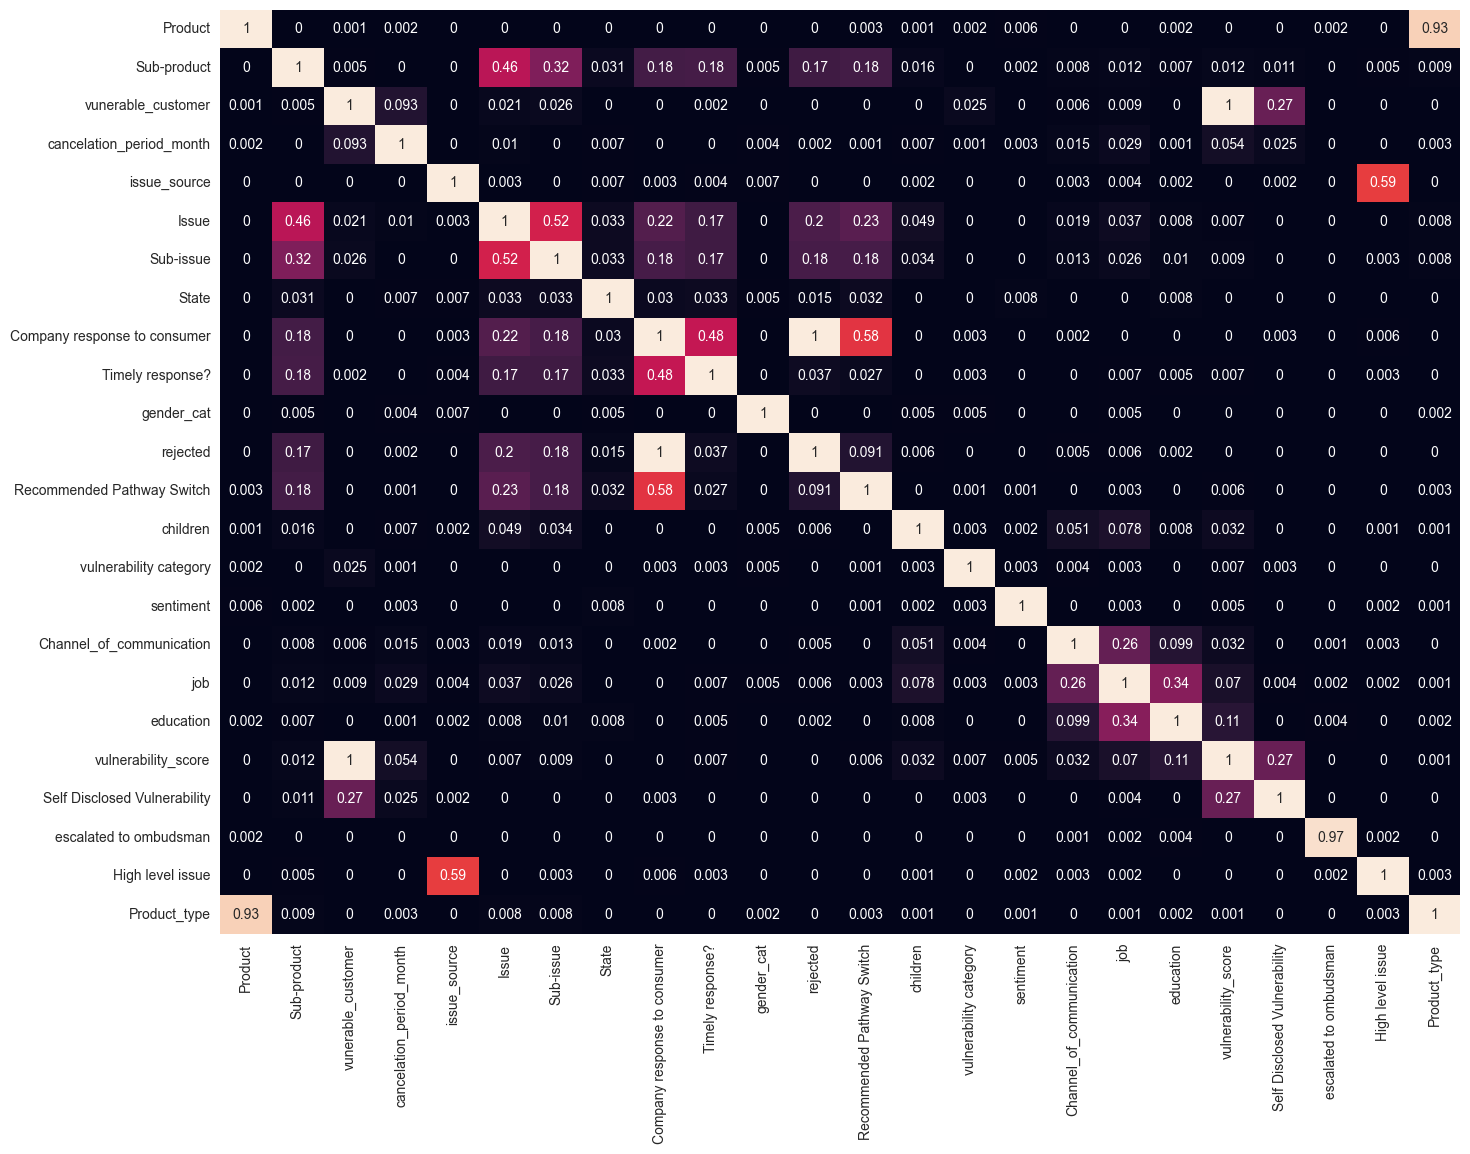

In [59]:
corr_cat = pd.DataFrame(data=data, index=cat_columns, columns=cat_columns)


plt.figure(figsize=(16, 12))
sns.heatmap(corr_cat, annot=True, cbar=False)
plt.show()

In [60]:
correlated_cols = set()
for name, row in corr_cat.iterrows():
    row = row.loc[:name][:-1]
    if len(row[row >= 0.5]) > 0:
        correlated_cols.add(name)
    
df.drop(correlated_cols, axis=1, inplace=True)
print(f"Colinear Features that has been dropped are...", correlated_cols)

Colinear Features that has been dropped are... {'Recommended Pathway Switch', 'rejected', 'Product_type', 'Sub-issue', 'vulnerability_score', 'High level issue'}


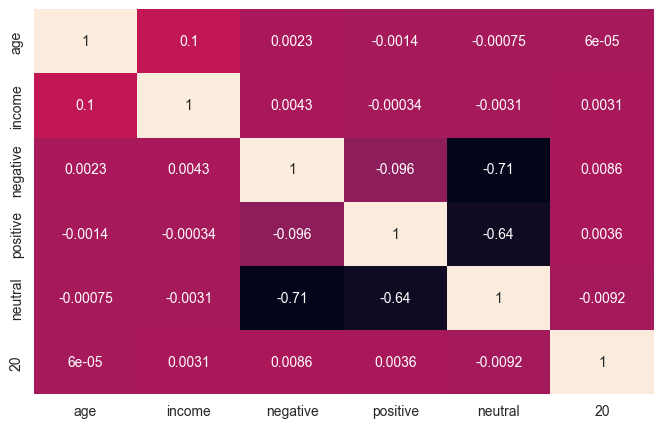

In [61]:
corr = df.select_dtypes(np.number).corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cbar=False)
plt.show()

In [62]:
correlated_cols = set()
for name, row in corr.iterrows():
    row = row.loc[:name][:-1]
    if len(row[row >= 0.5]) > 0:
        correlated_cols.add(name)
    
    if len(row[row <= -0.5]) > 0:
        correlated_cols.add(name)
    
df.drop(correlated_cols, axis=1, inplace=True)
print(f"Colinear Features that has been dropped are...", correlated_cols)

Colinear Features that has been dropped are... {'neutral'}


In [63]:
df["children"] = df["children"].astype("int64")
df["Self Disclosed Vulnerability"] = df["Self Disclosed Vulnerability"].astype("int64")
df["escalated to ombudsman"] = df["escalated to ombudsman"].astype("int64")

In [64]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

for col in df.select_dtypes("O").drop(["Consumer complaint narrative", "vulnerability_level"], axis=1).columns:
    df[col] = encoder.fit_transform(df[col])

In [65]:
import re
import nltk
nltk.download("wordnet")
nltk.download("stopwords")

lemmatizer = nltk.stem.WordNetLemmatizer()
STOPWORDS = list(nltk.corpus.stopwords.words("english"))
STOPWORDS.append("XX")
STOPWORDS.append("XXXX")
STOPWORDS.append("xxxxxxxx")
STOPWORDS.append("xxxxxxxxxxxx")


# Function to clean the data
def clean_data(txt):
    txt = txt.lower()                             # lowering text
    txt = re.sub(r'\n', ' ', txt)                 # Removing Newline
    txt = re.sub(r"[^a-zA-Z]"," ", txt)        # Removing all special characters
    txt = " ".join([lemmatizer.lemmatize(i) for i in txt.split() if i not in STOPWORDS])   # Removing stopwrods and applying lemmatization
    return txt

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jaynahalai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jaynahalai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [66]:
df["Consumer complaint narrative"] = df["Consumer complaint narrative"].apply(clean_data)

In [67]:
X = df["Consumer complaint narrative"]
df.drop("Consumer complaint narrative", axis=1, inplace=True)

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=2000, min_df=2)

vec = vectorizer.fit_transform(X).toarray()

In [69]:
df_vec = pd.DataFrame(data=vec, columns=vectorizer.get_feature_names_out())

In [70]:
from sklearn.decomposition import PCA

svd = PCA(n_components=100)
X_reduced = svd.fit_transform(df_vec)

In [71]:
df_vec_reduced = pd.DataFrame(data=X_reduced, columns=svd.get_feature_names_out())

In [72]:
df_new = pd.concat([df, df_vec_reduced], axis=1)

In [84]:
df_new.head()

,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,State,Company response to consumer,Timely response?,gender_cat,age,income,children,vulnerability category,negative,positive,sentiment,Channel_of_communication,job,education,20,vulnerability_level,Self Disclosed Vulnerability,escalated to ombudsman,pca0,...,pca75,pca76,pca77,pca78,pca79,pca80,pca81,pca82,pca83,pca84,pca85,pca86,pca87,pca88,pca89,pca90,pca91,pca92,pca93,pca94,pca95,pca96,pca97,pca98,pca99
0,13,15,0,3,8,110,15,1,1,1,27.000000,72578.64234,0,9,0.037,0.189,0,0,3,1,1523,Level 0 - not vulnerable,0,0,0.130527,...,0.001104,-0.001496,0.014451,-0.003166,0.087877,-0.045771,-0.007075,0.066605,0.007398,-0.001382,-0.013862,-0.090429,-0.022867,-0.043762,-0.036527,-0.013579,-0.006101,-0.053329,-0.009871,0.025449,0.026431,0.000708,-0.014570,-0.009910,0.017365
1,8,15,0,2,4,110,31,1,1,0,29.000000,55951.19927,1,12,0.084,0.036,1,1,7,1,1514,Level 0 - not vulnerable,0,0,-0.117332,...,-0.084404,0.196815,-0.081163,-0.176445,0.104686,-0.064446,0.080325,-0.138608,0.036763,0.027647,-0.066500,-0.084085,-0.013180,-0.039484,-0.050349,0.011242,0.009605,-0.040800,0.049014,0.021731,0.030355,-0.056368,0.027780,-0.063174,0.044801
2,1,15,0,1,4,110,24,1,1,1,38.000000,36691.68277,1,5,0.079,0.034,1,1,5,1,1551,Level 0 - not vulnerable,0,0,0.041564,...,-0.074700,0.179290,-0.072869,-0.170812,0.093078,-0.061119,0.074235,-0.133806,0.036613,0.030003,-0.061041,-0.078778,-0.019122,-0.037689,-0.057287,0.003610,0.014197,-0.044199,0.049717,0.010397,0.025836,-0.053399,0.028948,-0.055783,0.044235
3,9,15,0,3,7,110,35,1,1,0,64.000000,52277.27409,3,5,0.108,0.108,1,4,4,2,1517,Level 0 - not vulnerable,0,0,0.011165,...,0.116114,0.009826,-0.014770,-0.042615,-0.094864,0.022988,0.011806,-0.002946,0.031705,0.017107,0.003012,-0.027583,0.061353,0.023419,-0.008050,0.000818,-0.067115,0.011520,-0.013621,-0.070394,-0.023104,0.007024,0.002564,-0.002539,-0.031952
4,9,40,0,0,8,157,46,1,1,0,36.388486,54189.93763,1,2,0.000,0.091,1,0,5,2,1511,Level 0 - not vulnerable,0,0,-0.208047,...,-0.013259,0.008550,-0.027699,0.001328,0.071551,-0.036734,0.001276,0.002042,-0.039013,0.017810,0.009761,0.015256,-0.031127,-0.037798,0.048845,-0.007295,0.043566,-0.025920,-0.011525,-0.056027,-0.006298,0.004051,-0.009599,-0.054503,0.002362


In [86]:
df_new['vulnerability_level']= df_new['vulnerability_level'].map({
    'Level 0 - not vulnerable':0,
    'Level 1 - vulnerability prone':1,
    'Level 2 - mild vulnerability':2,
    'Level 3 - moderate vulnerability':3,
    'Level 4 - high vulnerability':4})

In [88]:
X = df_new.drop("vulnerability_level", axis=1)
y = df_new.vulnerability_level

In [89]:
def make_plots(feature, title="", limited=False, n=10):
    print("Total unique values are: ", len(feature.value_counts()), "\n\n")
    print("Category\tValue\n")
    if limited:
        data = feature.value_counts()[0:n]
    else:
        data = feature.value_counts()
    print(data)
    categories_num = len(data)
    #plotting bar-plot and pie chart
    sns.set_style('darkgrid')
    plt.figure(figsize=(16,5))
    plt.subplot(1,2,1)
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45)
    plot = sns.barplot(x=data.index, y=data.values, edgecolor="white", palette=sns.palettes.color_palette("icefire"))
    total = len(feature)
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.08
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y), size = 12)
    
    plt.subplot(1,2,2)
    labels = data.index
    plt.pie(x=data, autopct="%.1f%%", explode=[0.02]*categories_num, labels=labels, pctdistance=0.5)
    plt.title(title, fontsize=16)
    plt.show()

Total unique values are:  5 


Category	Value

vulnerability_level
0    191870
3      3188
2      2847
4      1235
1       117
Name: count, dtype: int64


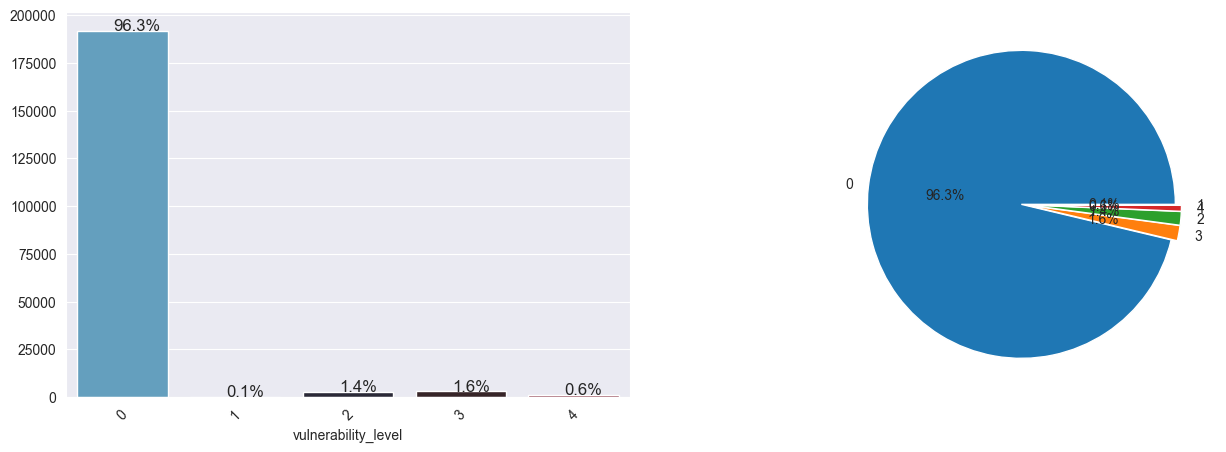

In [90]:
make_plots(y)

In [98]:
# Balancing data
from imblearn.over_sampling import SMOTE
sampler = SMOTE()
X, y = sampler.fit_resample(X, y)

AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
# from imblearn.over_sampling import ADASYN

# sampler = ADASYN(random_state=42)

# X_resampled, y_resampled = sampler.fit_resample(X, y)

AttributeError: 'NoneType' object has no attribute 'split'

Total unique values are:  5 


Category	Value

vulnerability_level
0    191870
3      3188
2      2847
4      1235
1       117
Name: count, dtype: int64


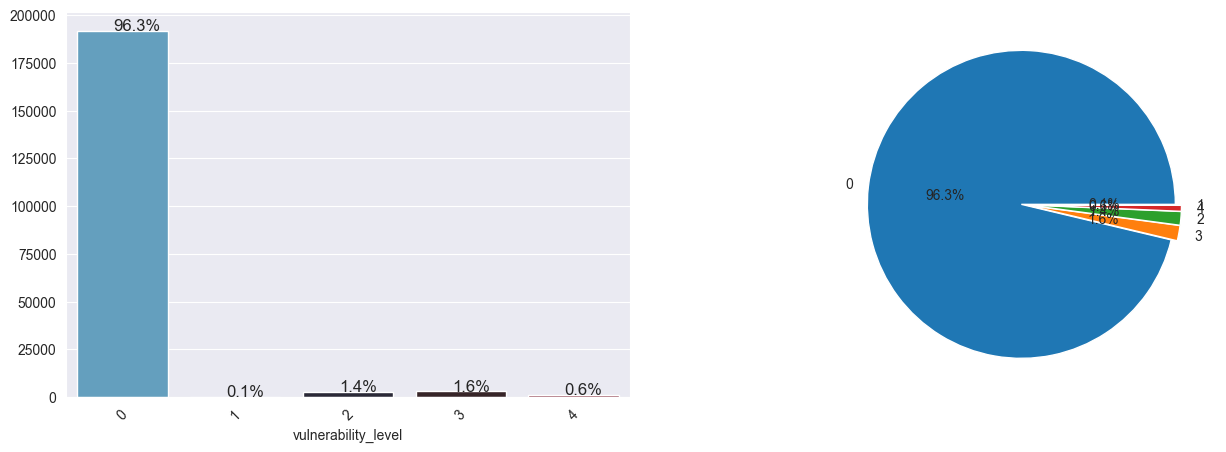

In [93]:
make_plots(y)

In [94]:
X.isna().sum().to_list()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [95]:
X.head()

,Product,Sub-product,vunerable_customer,cancelation_period_month,issue_source,Issue,State,Company response to consumer,Timely response?,gender_cat,age,income,children,vulnerability category,negative,positive,sentiment,Channel_of_communication,job,education,20,Self Disclosed Vulnerability,escalated to ombudsman,pca0,pca1,...,pca75,pca76,pca77,pca78,pca79,pca80,pca81,pca82,pca83,pca84,pca85,pca86,pca87,pca88,pca89,pca90,pca91,pca92,pca93,pca94,pca95,pca96,pca97,pca98,pca99
0,13,15,0,3,8,110,15,1,1,1,27.000000,72578.64234,0,9,0.037,0.189,0,0,3,1,1523,0,0,0.130527,-0.062853,...,0.001104,-0.001496,0.014451,-0.003166,0.087877,-0.045771,-0.007075,0.066605,0.007398,-0.001382,-0.013862,-0.090429,-0.022867,-0.043762,-0.036527,-0.013579,-0.006101,-0.053329,-0.009871,0.025449,0.026431,0.000708,-0.014570,-0.009910,0.017365
1,8,15,0,2,4,110,31,1,1,0,29.000000,55951.19927,1,12,0.084,0.036,1,1,7,1,1514,0,0,-0.117332,-0.023864,...,-0.084404,0.196815,-0.081163,-0.176445,0.104686,-0.064446,0.080325,-0.138608,0.036763,0.027647,-0.066500,-0.084085,-0.013180,-0.039484,-0.050349,0.011242,0.009605,-0.040800,0.049014,0.021731,0.030355,-0.056368,0.027780,-0.063174,0.044801
2,1,15,0,1,4,110,24,1,1,1,38.000000,36691.68277,1,5,0.079,0.034,1,1,5,1,1551,0,0,0.041564,-0.085187,...,-0.074700,0.179290,-0.072869,-0.170812,0.093078,-0.061119,0.074235,-0.133806,0.036613,0.030003,-0.061041,-0.078778,-0.019122,-0.037689,-0.057287,0.003610,0.014197,-0.044199,0.049717,0.010397,0.025836,-0.053399,0.028948,-0.055783,0.044235
3,9,15,0,3,7,110,35,1,1,0,64.000000,52277.27409,3,5,0.108,0.108,1,4,4,2,1517,0,0,0.011165,0.092193,...,0.116114,0.009826,-0.014770,-0.042615,-0.094864,0.022988,0.011806,-0.002946,0.031705,0.017107,0.003012,-0.027583,0.061353,0.023419,-0.008050,0.000818,-0.067115,0.011520,-0.013621,-0.070394,-0.023104,0.007024,0.002564,-0.002539,-0.031952
4,9,40,0,0,8,157,46,1,1,0,36.388486,54189.93763,1,2,0.000,0.091,1,0,5,2,1511,0,0,-0.208047,-0.031529,...,-0.013259,0.008550,-0.027699,0.001328,0.071551,-0.036734,0.001276,0.002042,-0.039013,0.017810,0.009761,0.015256,-0.031127,-0.037798,0.048845,-0.007295,0.043566,-0.025920,-0.011525,-0.056027,-0.006298,0.004051,-0.009599,-0.054503,0.002362


In [96]:
y.unique()

array([0, 2, 3, 4, 1])

 'Level 0 - not vulnerable',

 'Level 1 - vulnerability prone'

 'Level 2 - mild vulnerability',
 
 'Level 3 - moderate vulnerability',
 
 'Level 4 - high vulnerability'

In [97]:
y.value_counts()

vulnerability_level
0    191870
3      3188
2      2847
4      1235
1       117
Name: count, dtype: int64